Enter total bridge length (e.g., 6.0): 9
Enter number of bottom panels (even number, e.g., 4 or 6): 8
Enter bridge height (e.g., 1.5): 10
Enter downward load in Newtons (e.g., 400000): 1200
Enter bottom node index to load (0 to 8): 6


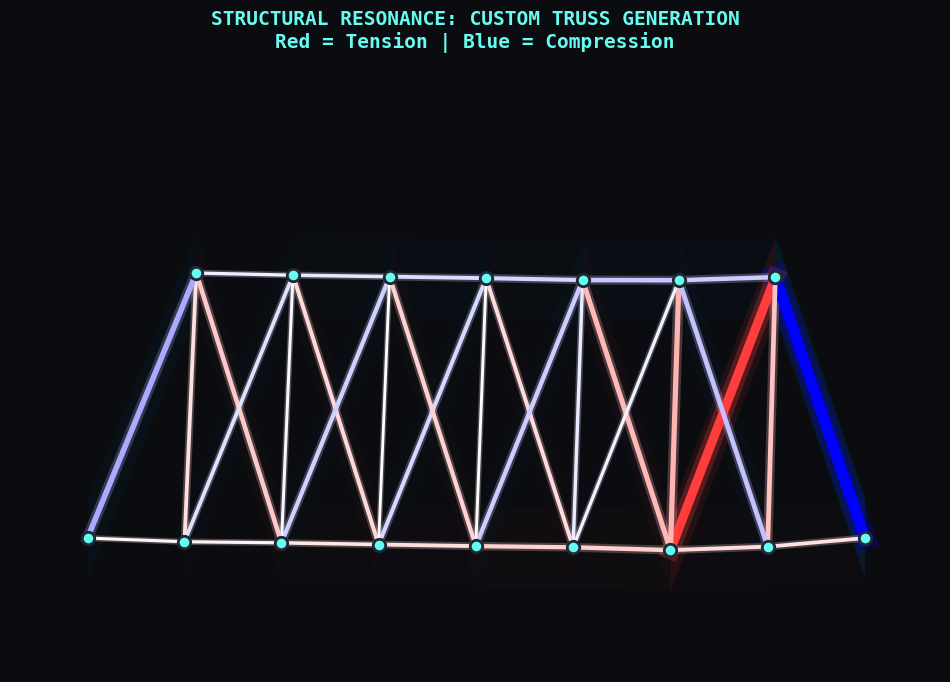

In [1]:
import numpy as np
import matplotlib.pyplot as plt
L_total = float(input("Enter total bridge length (e.g., 6.0): "))
num_panels = int(input("Enter number of bottom panels (even number, e.g., 4 or 6): "))
H_bridge = float(input("Enter bridge height (e.g., 1.5): "))
P_load = float(input("Enter downward load in Newtons (e.g., 400000): "))
load_node = int(input(f"Enter bottom node index to load (0 to {num_panels}): "))

# Generate Nodes
nodes = []
dx = L_total / num_panels
for i in range(num_panels + 1):
    nodes.append([i * dx, 0.0])  # Bottom chord nodes
for i in range(1, num_panels):
    nodes.append([i * dx, H_bridge])  # Top chord nodes
nodes = np.array(nodes)
num_nodes = len(nodes)

# Generate Elements
elements = []
for i in range(num_panels):
    elements.append([i, i + 1])  # Bottom Chord
for i in range(num_panels + 1, num_nodes - 1):
    elements.append([i, i + 1])  # Top Chord
for i in range(1, num_panels):   # Verticals and Diagonals
    top_idx = num_panels + i
    elements.append([i, top_idx])
    elements.append([i - 1, top_idx])
    elements.append([i + 1, top_idx])

# Filter duplicates
elements = np.array(list(set(tuple(sorted(e)) for e in elements)))
num_elements = len(elements)

# Material & Boundary Conditions
E, A = 210e9, 0.005
restraints = [(0, 0), (0, 1), (num_panels, 1)]  # Pin left, roller right
forces = np.array([[load_node, 1, -P_load]])
K_global = np.zeros((2 * num_nodes, 2 * num_nodes))
element_data = []

for ext in elements:
    n1, n2 = ext
    x1, y1 = nodes[n1]
    x2, y2 = nodes[n2]

    L = np.hypot(x2 - x1, y2 - y1)
    cos, sin = (x2 - x1) / L, (y2 - y1) / L

    T = np.array([-cos, -sin, cos, sin])
    k_local = (E * A / L) * np.outer(T, T)

    dofs = [2 * n1, 2 * n1 + 1, 2 * n2, 2 * n2 + 1]
    for i in range(4):
        for j in range(4):
            K_global[dofs[i], dofs[j]] += k_local[i, j]

    element_data.append({'L': L, 'T': T, 'dofs': dofs})

F_global = np.zeros(2 * num_nodes)
for f in forces:
    F_global[int(f[0]) * 2 + int(f[1])] = f[2]

for node, dof in restraints:
    idx = node * 2 + dof
    K_global[idx, idx] += 1e15

displacements = np.linalg.solve(K_global, F_global)

element_stresses = []
for idx, elem in enumerate(element_data):
    disp_elem = displacements[elem['dofs']]
    strain = np.dot(elem['T'], disp_elem) / elem['L']
    element_stresses.append(E * strain)
element_stresses = np.array(element_stresses)
fig, ax = plt.subplots(figsize=(12, 8), facecolor='#0B0C10')
ax.set_facecolor('#0B0C10')

# Scaling deformation dynamically relative to the bridge length
deformation_scale = (L_total / (np.max(np.abs(displacements)) if np.max(np.abs(displacements)) > 0 else i)) * 0.05
def_nodes = nodes + displacements.reshape(num_nodes, 2) * deformation_scale

max_stress = max(np.abs(element_stresses))
norm_stresses = element_stresses / (max_stress if max_stress != 0 else 1)

# Render background aura fields
for i, (n1, n2) in enumerate(elements):
    x_coords = [def_nodes[n1, 0], def_nodes[n2, 0]]
    y_coords = [def_nodes[n1, 1], def_nodes[n2, 1]]
    color = '#FF4136' if norm_stresses[i] >= 0 else '#0074D9'
    ax.fill_between(x_coords, [y + (H_bridge*0.15) for y in y_coords], [y - (H_bridge*0.15) for y in y_coords],
                    color=color, alpha=abs(norm_stresses[i]) * 0.12, lw=0)

# Render generative frame lines
for i, (n1, n2) in enumerate(elements):
    x_coords = [def_nodes[n1, 0], def_nodes[n2, 0]]
    y_coords = [def_nodes[n1, 1], def_nodes[n2, 1]]
    stress_ratio = norm_stresses[i]

    if stress_ratio >= 0:
        color = (1.0, 1.0 - stress_ratio, 1.0 - stress_ratio)
    else:
        color = (1.0 - abs(stress_ratio), 1.0 - abs(stress_ratio), 1.0)

    lw = 2 + (abs(stress_ratio) * 6)
    ax.plot(x_coords, y_coords, color=color, linewidth=lw, zorder=3, solid_capstyle='round')
    ax.plot(x_coords, y_coords, color=color, linewidth=lw*2, alpha=0.25, zorder=2)

ax.scatter(def_nodes[:, 0], def_nodes[:, 1], color='#66FCF1', s=80, zorder=4, edgecolors='#1F2833', linewidths=2)

ax.set_xlim(-L_total*0.1, L_total*1.1)
ax.set_ylim(-H_bridge*0.5, H_bridge*1.8)
ax.axis('off')

plt.title("STRUCTURAL RESONANCE: CUSTOM TRUSS GENERATION\nRed = Tension | Blue = Compression",
          color='#66FCF1', fontsize=14, fontfamily='monospace', weight='bold')
plt.show()